# Análisis exploratorio de incidencia delictiva en México

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [31]:
df = pd.read_csv('data/delitos.csv')

#### Ejercicio 1: Elige 3 estados de la república y grafica una serie de tiempo de la frecuencia abosluta de homicidios dolosos de enero 2015 a julio 2019 en estas tres entidades

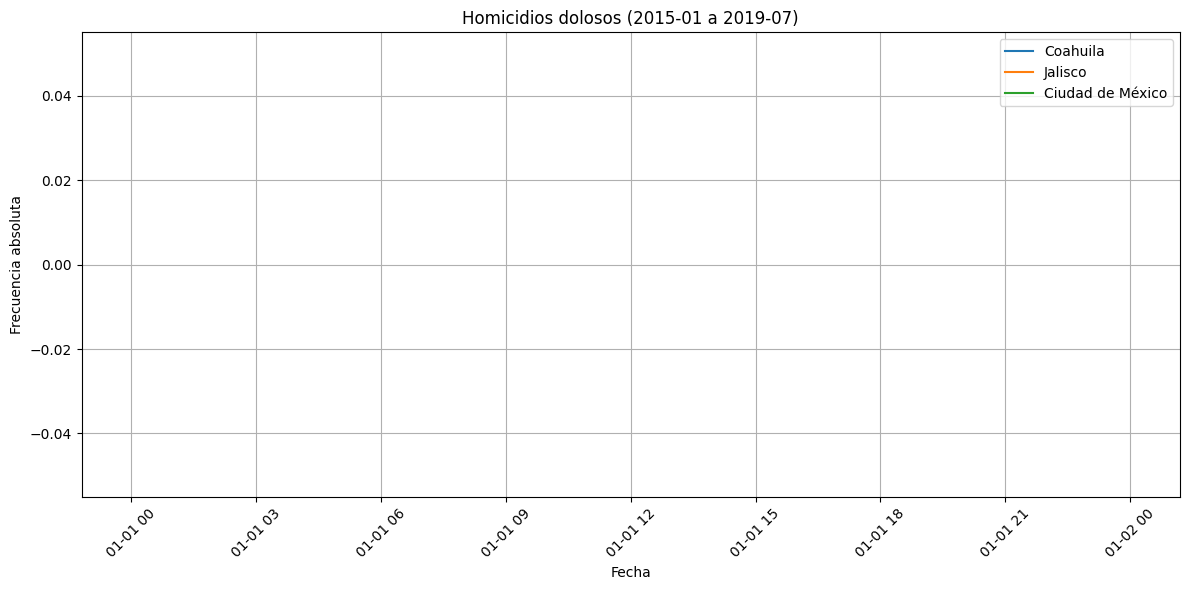

In [32]:
# 2. Filtrar solo homicidios dolosos
homicidios = df[df["tipo_de_delito"] == "Homicidio doloso"]

# 3. Elegir tres estados
estados = ["Coahuila", "Jalisco", "Ciudad de México"]
homicidios_estados = homicidios[homicidios["entidad"].isin(estados)]

# 4. Convertir la columna 'fecha' a tipo datetime
homicidios_estados["fecha"] = pd.to_datetime(homicidios_estados["fecha"])

# 5. Filtrar rango de tiempo (enero 2015 a julio 2019)
mask = (homicidios_estados["fecha"] >= "2015-01-01") & (homicidios_estados["fecha"] <= "2019-07-31")
homicidios_periodo = homicidios_estados[mask]

# 6. Agrupar por fecha y entidad
serie = homicidios_periodo.groupby(["fecha", "entidad"])["frecuencia"].sum().reset_index()

# 7. Graficar
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
for estado in estados:
    datos_estado = serie[serie["entidad"] == estado]
    plt.plot(datos_estado["fecha"], datos_estado["frecuencia"], label=estado)

plt.title("Homicidios dolosos (2015-01 a 2019-07)")
plt.xlabel("Fecha")
plt.ylabel("Frecuencia absoluta")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Ejercicio 2: Contetas las siguientes  preguntas:
1. ¿Cuántos homicidios dolosos hubo en Colima en el 2018?
2. ¿Cuantos robos de vehículo automotor ha habido en el 2019?
3. Obten la suma de homicidos dolosos y feminidios en toda la República Mexicana en cada año.
4. ¿En qué mes y en qué municipio ha ocurrido el mayor número de feminicidios?
5. ¿En qué año y en qué estado ha ocurrido el mayor número de feminicidios?

1- Homicidios dolosos en Colima en 2018
Total: 651 casos
Se contabilizaron 651 homicidios dolosos en el estado de Colima durante el año 2018.
2- Robos de vehículo automotor en 2019
Total: 152,304 casos
En todo México, se registraron 152,304 robos de vehículo automotor durante el año 2019.
3- 2015 = 20,525; 2016 = 23,327; 2017 = 29,103; 2018 = 34,173; 2019 = 36,217
4- Mes y municipio con más feminicidios
Mes: Diciembre 2017
Municipio: Culiacán
Culiacán registró el mayor número de feminicidios en un solo mes, con un pico en diciembre de 2017.
5- Año y estado con más feminicidios
Año: 2019
Estado: Veracruz

#### Ejercicio 3: Haz una gráfica de pastel de tipos de delito. Deberás crear una gráfica para cada año. Utilzia la función subplots de matplotlib

/tmp/ipykernel_18902/2898508091.py:25: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


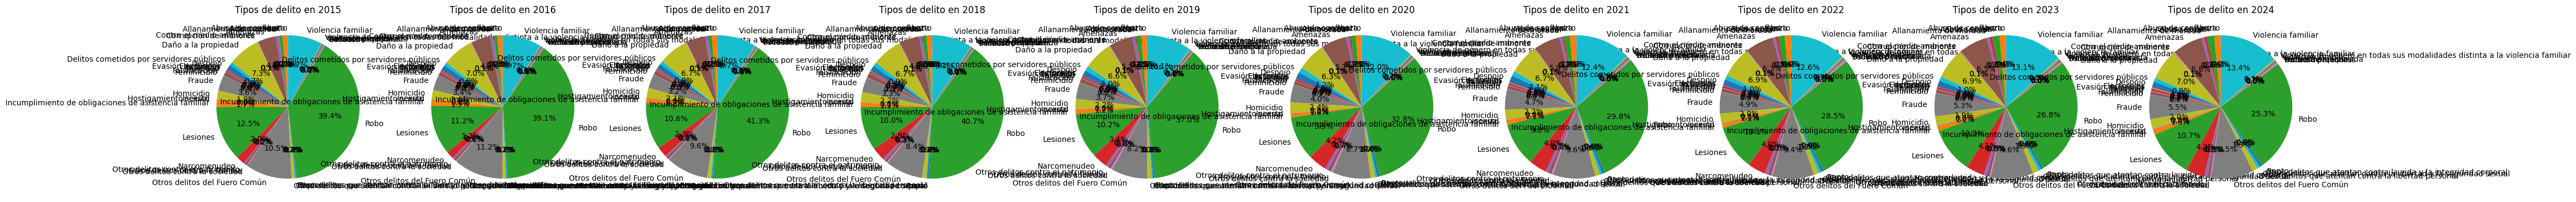

In [33]:

# 2. Agrupar por año y tipo de delito
delitos_por_anio = df.groupby(["anio", "tipo_de_delito"])["frecuencia"].sum().reset_index()

# 3. Obtener lista de años únicos
anios = sorted(delitos_por_anio["anio"].unique())

# 4. Crear subplots (una gráfica por año)
fig, axes = plt.subplots(1, len(anios), figsize=(5*len(anios), 6))

# Si solo hay un año, axes no es iterable
if len(anios) == 1:
    axes = [axes]

# 5. Generar gráfica de pastel para cada año
for i, anio in enumerate(anios):
    datos_anio = delitos_por_anio[delitos_por_anio["anio"] == anio]
    axes[i].pie(
        datos_anio["frecuencia"],
        labels=datos_anio["tipo_de_delito"],
        autopct="%1.1f%%",
        startangle=90
    )
    axes[i].set_title(f"Tipos de delito en {anio}")

plt.tight_layout()
plt.show()

---
#### Calcula la tasa por 100,000 habitantes
##### Tasa por 100,000 habitantes
Mostrar el total de delitos en una entidad no nos sirve de mucho. Es mucho más útil calcular la tasa de incidencia delictiva por cada 100,000 habitantes

$$
tasa = \frac{delitos\space totales}{población} \times 100,000
$$

Esta tasa la podemos anualizar multiplicándola por un factor de 12
$$
tasa\space anualizada = tasa \times 12
$$

Población por entidad federativa según [la encuesta intercensal 2015](https://www.inegi.org.mx/programas/intercensal/2015/)

No tienes que descargar nada. Ya están los datos en la carpeta data

In [ ]:
pobs = pd.read_csv('data/poblacion_entidades_2015.csv', encoding='iso-8859-1', sep=";")
pobs = pobs[['Cve_Entidad', 'Entidad', 'Poblacion']]
pobs = pobs.rename(columns={'Cve_Entidad':'clave_entidad', 'Entidad':'entidad', 'Poblacion':'poblacion'})
pobs.head()

In [35]:

# 1. Cargar delitos
delitos = pd.read_csv("data/delitos.csv")

# 2. Cargar población
pobs = pd.read_csv("data/poblacion_entidades_2015.csv", encoding="iso-8859-1", sep=";")
pobs = pobs[['Cve_Entidad', 'Entidad', 'Poblacion']]
pobs = pobs.rename(columns={'Cve_Entidad':'clave_ent', 'Entidad':'entidad', 'Poblacion':'poblacion'})

# 3. Agrupar delitos por entidad y año
delitos_totales = delitos.groupby(["anio", "clave_ent", "entidad"])["frecuencia"].sum().reset_index()

# 4. Unir con población
df = delitos_totales.merge(pobs, on=["clave_ent", "entidad"], how="left")

# 5. Calcular tasa por 100,000 habitantes
df["tasa_100k"] = (df["frecuencia"] / df["poblacion"]) * 100000

# 6. Calcular tasa anualizada
df["tasa_anualizada"] = df["tasa_100k"] * 12

# 7. Mostrar resultados
print(df.head())

   anio  clave_ent               entidad  frecuencia  poblacion    tasa_100k  \
0  2015          1        Aguascalientes     23212.0  1312544.0  1768.474047   
1  2015          2       Baja California    119944.0  3315766.0  3617.384339   
2  2015          3   Baja California Sur     21415.0   712029.0  3007.602218   
3  2015          4              Campeche      1886.0   899931.0   209.571623   
4  2015          5  Coahuila de Zaragoza     46569.0  5217908.0   892.484114   

   tasa_anualizada  
0     21221.688568  
1     43408.612067  
2     36091.226621  
3      2514.859473  
4     10709.809372  
